<a href="https://colab.research.google.com/github/Kashyapdhar05/KashyapDhar_Deep_Learning-/blob/main/exp_11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Training Autoencoder...
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


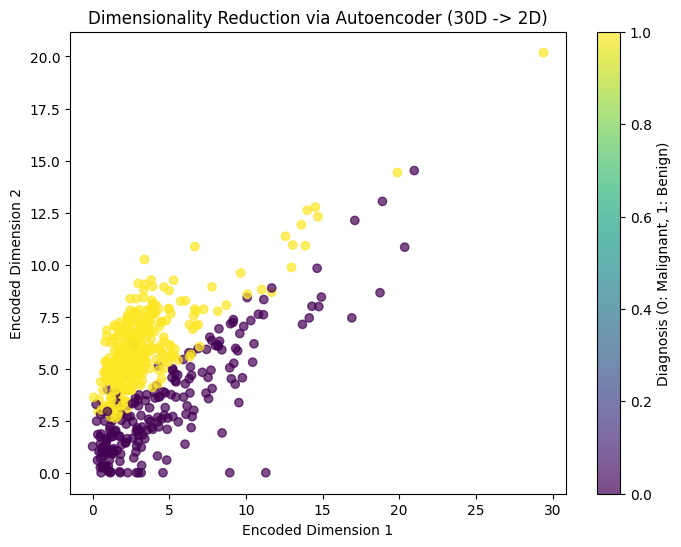

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler

# 1. Load and Scale Data
data = load_breast_cancer()
X = StandardScaler().fit_transform(data.data)
input_dim = X.shape[1]  # 30 features

# 2. Define the Autoencoder Architecture
# Encoder: Compresses 30 features down to 2
input_layer = Input(shape=(input_dim,))
encoded = Dense(16, activation='relu')(input_layer)
encoded = Dense(2, activation='relu')(encoded) # The "Bottleneck"

# Decoder: Reconstructs 2 features back to 30
decoded = Dense(16, activation='relu')(encoded)
output_layer = Dense(input_dim, activation='linear')(decoded)

# The Full Model (End-to-End)
autoencoder = Model(input_layer, output_layer)

# The Encoder Model (To extract the reduced dimensions)
encoder = Model(input_layer, encoded)

# 3. Compile and Train
autoencoder.compile(optimizer='adam', loss='mse')
print("Training Autoencoder...")
autoencoder.fit(X, X, epochs=100, batch_size=16, verbose=0)

# 4. Reduce Dimensions
X_reduced = encoder.predict(X)

# 5. Visualize the Result
plt.figure(figsize=(8, 6))
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=data.target, cmap='viridis', alpha=0.7)
plt.colorbar(label='Diagnosis (0: Malignant, 1: Benign)')
plt.title('Dimensionality Reduction via Autoencoder (30D -> 2D)')
plt.xlabel('Encoded Dimension 1')
plt.ylabel('Encoded Dimension 2')
plt.show()